# 🔥 Modelo_Final_Unseen_Daniele — Prueba de Fuego de Generalización (PASO 4)
### Reto de Inteligencia Artificial — Detección de Audio Spoofing
**Dataset:** ASVspoof2019 — Logical Access (LA) — Conjunto de Entrenamiento  
**Autor:** Daniele  
**Versión:** V1  

---
## Objetivo de este Notebook

Este es el **notebook definitivo** y la prueba más exigente del proyecto. Su misión es responder una sola pregunta:

> **¿Aprendió el modelo a detectar "voz sintética" como concepto general, o solo memorizó los patrones de los 4 primeros ataques?**

### Protocolo de la Prueba de Fuego:
| Fase | Ataques incluidos | Rol |
|------|-------------------|-----|
| **Entrenamiento** | A01, A02, A03, A04 (spoof) + bonafide | Lo que el modelo VE |
| **Test (sellado)** | A05, A06 (spoof) + bonafide | Lo que el modelo NUNCA VIO |

### Configuración heredada del Paso 3:
- **Algoritmo:** Random Forest (ganador absoluto del Paso 3)
- **Hiperparámetros:** n_estimators=200, max_depth=15, min_samples_leaf=2
- **Features:** 15 features óptimas (de 34 originales)
- **N óptimo:** 3,200 muestras (Learning Curve Paso 2)

---
## 📝 PARA TU BLOC DE NOTAS — JUSTIFICACIÓN GLOBAL DEL PASO 4

**¿Por qué esta prueba es la más importante del proyecto?**  
Los pasos anteriores (M1, M2, M3) usaron un split train/test aleatorio: el test contenía ejemplos de TODOS los ataques (A01-A06) en proporciones similares al train. Eso no es un test de generalización real, es solo un test de interpolación. El Paso 4 es diferente: **el modelo nunca ha visto A05 ni A06 durante el entrenamiento**. Si el modelo detecta bien el spoofing en A05-A06, significa que aprendió algo genuino sobre la naturaleza de la voz sintética. Si falla, significa que sobreajustó los patrones acústicos específicos de A01-A04.

**¿Por qué usamos Random Forest y no otro algoritmo?**  
El Paso 3 generó una tabla comparativa M1→M2→M3. El modelo M1 baseline (RF, n_estimators=100, 34 features) obtuvo el mejor Test F1 (0.9313) y AUC (0.9785). Pero el modelo M3 (RF optimizado, 15 features) tiene mejor equilibrio entre rendimiento y parsimonia. Para la Prueba de Fuego usaremos el **RF con hiperparámetros optimizados del Paso 2** (n_estimators=200, max_depth=15) sobre las **15 features del Paso 3**, que es la configuración más honesta: regularizada, interpretable y eficiente.

**¿Qué esperamos encontrar en el análisis de overfitting de este paso?**  
Esperamos que el F1 en A05-A06 sea MENOR que el F1 en A01-A04 (distributional shift). La pregunta es cuánto menor. Si el F1 cae por debajo de 0.70, el modelo memorizó. Si se mantiene por encima de 0.80, el modelo aprendió características genuinas. Un análisis por ataque individual nos dirá qué sistema TTS/vocoder fue más fácil o difícil de detectar.

In [13]:
# ============================================================
#  BLOQUE 1 — IMPORTACIONES Y CONFIGURACIÓN GLOBAL
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import json
import os
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)
plt.rcParams['figure.dpi']       = 110
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
N_FOLDS      = 5
DATA_PATH    = '../Obtencion_Metricas/dataset_caracteristicas_train_V1_ALL.csv'

# ── Configuración heredada del Paso 3 ──────────────────────
TRAIN_ATTACKS = ['A01', 'A02', 'A03', 'A04']
TEST_ATTACKS  = ['A05', 'A06']

BEST_PARAMS = {
    'n_estimators'    : 200,
    'max_depth'       : 15,
    'min_samples_leaf': 2,
    'n_jobs'          : -1,
    'random_state'    : RANDOM_STATE
}

# 15 features óptimas del Paso 3 (ranking consolidado MDI + XGB + Permutation)
FINAL_FEATURES = [
    'mfcc_4_std', 'mfcc_6_mean', 'mfcc_10_std', 'mfcc_8_std',
    'mfcc_9_mean', 'mfcc_8_mean', 'mfcc_9_std', 'mfcc_7_mean',
    'mfcc_1_std', 'spectral_bandwidth_mean', 'mfcc_2_mean',
    'signal_mean', 'mfcc_11_mean', 'mfcc_5_mean', 'spectral_rolloff_mean'
]

print('✅ Configuración cargada.')
print(f'  Ataques de TRAIN : {TRAIN_ATTACKS}')
print(f'  Ataques de TEST  : {TEST_ATTACKS}')
print(f'  Algoritmo        : Random Forest')
print(f'  Hiperparámetros  : {BEST_PARAMS}')
print(f'  Features         : {len(FINAL_FEATURES)} features óptimas')

✅ Configuración cargada.
  Ataques de TRAIN : ['A01', 'A02', 'A03', 'A04']
  Ataques de TEST  : ['A05', 'A06']
  Algoritmo        : Random Forest
  Hiperparámetros  : {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 2, 'n_jobs': -1, 'random_state': 42}
  Features         : 15 features óptimas


---
## SECCIÓN 1 — Construcción del Dataset por Grupos de Ataque

### 📝 PARA TU BLOC DE NOTAS — DECISIÓN DE PARTICIÓN Y BALANCEO

**¿Por qué esta partición es fundamentalmente diferente a los pasos anteriores?**  
En M1-M3, la partición train/test era **aleatoria estratificada**: ambos conjuntos contenían muestras de todos los ataques. En el Paso 4, la partición es **estructural por ataque**: el test contiene ataques que el modelo nunca vio. Esto simula el escenario real donde aparecen nuevos sistemas TTS en producción.

**¿Por qué es crítico hacer undersampling balanceado antes de entrenar?**  
ASVspoof2019 es un dataset naturalmente desbalanceado: hay muchos más ejemplos de spoof que de bonafide (el ratio puede ser 10:1 o mayor). Si entrenamos con ese desbalance, el modelo aprende a predecir siempre 'spoof' y obtiene F1 artificialmente alto. El undersampling fuerza al modelo a aprender la **frontera de decisión** entre las dos clases en lugar de explotar el desbalance. Esta es exactamente la misma estrategia usada en M1, M2 y M3 (N_PER_CLASS=2500).

**¿Cómo se hace el undersampling manteniendo proporciones?**  
Para el spoof: se muestrea proporcionalmente dentro de cada ataque (ej. si A01 tiene el doble de muestras que A02, se toman el doble de muestras de A01). Así se preserva la distribución relativa entre ataques. Para bonafide: se muestrea directamente hasta N_PER_CLASS. El resultado es un dataset 50/50 en cada set.

**¿Qué nos dice el análisis de overfitting en este paso?**  
El gap entre el F1 en CV (A01-A04 balanceado) y el F1 en test (A05-A06 balanceado) mide la **generalización entre distribuciones de ataque**. Al estar ambos sets balanceados, el F1 es una métrica honesta y comparable entre sí.

In [14]:
# ============================================================
#  BLOQUE 2 — CARGA Y PARTICIÓN POR GRUPOS DE ATAQUE
# ============================================================
df_full = pd.read_csv(DATA_PATH)

print('Dataset cargado.')
print(f'  Total registros : {len(df_full):,}')
print(f'  Columnas        : {list(df_full.columns)}')
print()
print('Distribución por attack_id:')
print(df_full['attack_id'].value_counts().sort_index())
print()
print('Distribución por label:')
print(df_full['label'].value_counts())

Dataset cargado.
  Total registros : 25,380
  Columnas        : ['file_name', 'signal_mean', 'signal_std', 'rmse_mean', 'zcr_mean', 'tempo_bpm', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean', 'attack_id', 'label']

Distribución por attack_id:
attack_id
-      2580
A01    3800
A02    3800
A03    3800
A04    3800
A05    3800
A06    3800
Name: count, dtype: int64

Distribución por label:
label
spoof       22800
bonafide     2580
Name: count, dtype: int64


In [15]:
# ============================================================
#  BLOQUE 3 — SEPARACIÓN Y UNDERSAMPLING BALANCEADO
#             TRAIN: A01-A04 | TEST: A05-A06
# ============================================================
# ── Parámetros de balanceo (idénticos al pipeline M1-M3) ───
N_PER_CLASS_TRAIN = 2500   # muestras por clase en TRAIN
N_PER_CLASS_TEST  = 1000   # muestras por clase en TEST (unseen)

df_bonafide = df_full[df_full['label'] == 'bonafide'].copy()
df_spoof    = df_full[df_full['label'] == 'spoof'].copy()

# ── Spoof: separar por grupo de ataque ──────────────────────
df_spoof_train_raw = df_spoof[df_spoof['attack_id'].isin(TRAIN_ATTACKS)].copy()
df_spoof_test_raw  = df_spoof[df_spoof['attack_id'].isin(TEST_ATTACKS)].copy()

# ── TRAIN: undersampling proporcional por ataque (igual que M1-M3) ──
attack_counts_tr = df_spoof_train_raw['attack_id'].value_counts()
props_tr         = attack_counts_tr / attack_counts_tr.sum()
n_per_atk_tr     = (props_tr * N_PER_CLASS_TRAIN).astype(int)
deficit_tr       = N_PER_CLASS_TRAIN - n_per_atk_tr.sum()
for atk in n_per_atk_tr.nlargest(abs(deficit_tr)).index:
    n_per_atk_tr[atk] += int(np.sign(deficit_tr))

spoof_train_parts = []
for atk, n in n_per_atk_tr.items():
    subset = df_spoof_train_raw[df_spoof_train_raw['attack_id'] == atk]
    spoof_train_parts.append(subset.sample(n=min(n, len(subset)), random_state=RANDOM_STATE))
df_spoof_train = pd.concat(spoof_train_parts)

# ── TEST: undersampling proporcional por ataque ──────────────
attack_counts_te = df_spoof_test_raw['attack_id'].value_counts()
props_te         = attack_counts_te / attack_counts_te.sum()
n_per_atk_te     = (props_te * N_PER_CLASS_TEST).astype(int)
deficit_te       = N_PER_CLASS_TEST - n_per_atk_te.sum()
for atk in n_per_atk_te.nlargest(abs(deficit_te)).index:
    n_per_atk_te[atk] += int(np.sign(deficit_te))

spoof_test_parts = []
for atk, n in n_per_atk_te.items():
    subset = df_spoof_test_raw[df_spoof_test_raw['attack_id'] == atk]
    spoof_test_parts.append(subset.sample(n=min(n, len(subset)), random_state=RANDOM_STATE))
df_spoof_test = pd.concat(spoof_test_parts)

# ── Bonafide: dividir proporcionalmente train/test ───────────
df_bon_shuffled = df_bonafide.sample(frac=1, random_state=RANDOM_STATE)
prop_train_bon  = N_PER_CLASS_TRAIN / (N_PER_CLASS_TRAIN + N_PER_CLASS_TEST)
n_bon_train     = int(len(df_bon_shuffled) * prop_train_bon)

df_bon_train_raw = df_bon_shuffled.iloc[:n_bon_train]
df_bon_test_raw  = df_bon_shuffled.iloc[n_bon_train:]

# Undersample bonafide al mismo N_PER_CLASS de cada set
df_bon_train = df_bon_train_raw.sample(
    n=min(N_PER_CLASS_TRAIN, len(df_bon_train_raw)), random_state=RANDOM_STATE
)
df_bon_test = df_bon_test_raw.sample(
    n=min(N_PER_CLASS_TEST, len(df_bon_test_raw)), random_state=RANDOM_STATE
)

# ── Construir sets finales balanceados y mezclar ─────────────
df_train = pd.concat([df_spoof_train, df_bon_train]).sample(
    frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df_test  = pd.concat([df_spoof_test,  df_bon_test]).sample(
    frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

ALL_FEATURE_COLS = [c for c in df_full.columns if c not in ['file_name', 'attack_id', 'label']]

X_train = df_train[FINAL_FEATURES]
y_train = df_train['label']
X_test  = df_test[FINAL_FEATURES]
y_test  = df_test['label']

le          = LabelEncoder().fit(['bonafide', 'spoof'])
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print('=' * 68)
print('PARTICIÓN PRUEBA DE FUEGO — DATASET BALANCEADO (undersampling)')
print('=' * 68)
print(f'  TRAIN | Spoof (A01-A04): {len(df_spoof_train):>5,} | Bonafide: {len(df_bon_train):>5,} | Total: {len(df_train):>6,}')
print(f'  TEST  | Spoof (A05-A06): {len(df_spoof_test):>5,} | Bonafide: {len(df_bon_test):>5,} | Total: {len(df_test):>6,}')
print()
print('Distribución spoof en TRAIN (por ataque):')
print(df_train[df_train['label']=='spoof']['attack_id'].value_counts().sort_index().to_string())
print()
print('Distribución spoof en TEST — NUNCA VISTOS (por ataque):')
print(df_test[df_test['label']=='spoof']['attack_id'].value_counts().sort_index().to_string())
print()
print('Balance de clases en TRAIN:')
print(df_train['label'].value_counts().to_string())
print()
print('Balance de clases en TEST:')
print(df_test['label'].value_counts().to_string())
print()
print(f'  Features usadas : {len(FINAL_FEATURES)} de {len(ALL_FEATURE_COLS)}')

PARTICIÓN PRUEBA DE FUEGO — DATASET BALANCEADO (undersampling)
  TRAIN | Spoof (A01-A04): 2,500 | Bonafide: 1,842 | Total:  4,342
  TEST  | Spoof (A05-A06): 1,000 | Bonafide:   738 | Total:  1,738

Distribución spoof en TRAIN (por ataque):
attack_id
A01    625
A02    625
A03    625
A04    625

Distribución spoof en TEST — NUNCA VISTOS (por ataque):
attack_id
A05    500
A06    500

Balance de clases en TRAIN:
label
spoof       2500
bonafide    1842

Balance de clases en TEST:
label
spoof       1000
bonafide     738

  Features usadas : 15 de 34


---
## SECCIÓN 2 — Entrenamiento del Modelo Final

### 📝 PARA TU BLOC DE NOTAS — ENTRENAMIENTO SOBRE A01-A04

**¿Por qué NO hacemos búsqueda de hiperparámetros en este paso?**  
Los hiperparámetros ya están fijados en el Paso 2. Reoptimizarlos ahora sobre A01-A04 introduciría **data leakage conceptual**: estaríamos usando la señal de los 4 ataques para ajustar la capacidad del modelo. El Paso 4 es un test puro: configuración congelada del Paso 3, evaluación ciega en A05-A06.

**¿Por qué usamos validación cruzada sobre el train antes de evaluar en test?**  
La CV sobre A01-A04 nos da una referencia del rendimiento "esperado" (dentro de la distribución conocida). El gap entre la CV sobre A01-A04 y la evaluación en A05-A06 mide exactamente la degradación por cambio de distribución.

**¿Cómo justificamos la Learning Curve en este paso?**  
La Learning Curve aquí tiene una lectura diferente a los pasos anteriores. En M2 medíamos el plateau de generalización (cuántos datos necesitamos). En M4 medimos si el modelo aprende patrones **transferibles**: si la curva de validación sobre A01-A04 converge bien, el modelo internalizó la estructura del problema, no solo los ejemplos. Un modelo con buena convergencia tiene más probabilidad de generalizar a A05-A06.

In [16]:
# ============================================================
#  BLOQUE 4 — VALIDACIÓN CRUZADA SOBRE TRAIN (A01-A04)
# ============================================================
model = RandomForestClassifier(**BEST_PARAMS)

cv_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f'Ejecutando {N_FOLDS}-Fold CV sobre train (A01-A04)...')
cv_results = cross_validate(
    model, X_train, y_train_enc,
    cv=cv_skf,
    scoring={'f1': 'f1', 'roc_auc': 'roc_auc', 'recall': 'recall', 'precision': 'precision'},
    return_train_score=True,
    n_jobs=-1
)

metrics_order = ['f1', 'roc_auc', 'recall', 'precision']
print()
print('VALIDACIÓN CRUZADA — Train (A01-A04)')
print('=' * 62)
print(f'  {"Métrica":<12} {"Train (μ)":>10} {"Val (μ)":>10} {"GAP":>8}')
print('  ' + '-' * 44)
for m in metrics_order:
    tr  = cv_results[f'train_{m}'].mean()
    val = cv_results[f'test_{m}'].mean()
    gap = tr - val
    flag = '✅' if gap < 0.05 else ('⚠️' if gap < 0.10 else '❌')
    print(f'  {m:<12} {tr:>10.4f} {val:>10.4f} {gap:>+8.4f} {flag}')
print()
print('Entrenando modelo final sobre TODO el train (A01-A04)...')
model.fit(X_train, y_train_enc)
print('✅ Modelo entrenado.')

Ejecutando 5-Fold CV sobre train (A01-A04)...

VALIDACIÓN CRUZADA — Train (A01-A04)
  Métrica       Train (μ)    Val (μ)      GAP
  --------------------------------------------
  f1               0.9979     0.9463  +0.0516 ⚠️
  roc_auc          0.9999     0.9861  +0.0138 ✅
  recall           0.9960     0.9488  +0.0472 ✅
  precision        0.9998     0.9439  +0.0559 ⚠️

Entrenando modelo final sobre TODO el train (A01-A04)...
✅ Modelo entrenado.


---
## SECCIÓN 3 — Learning Curve sobre el Train (A01-A04)

### 📝 PARA TU BLOC DE NOTAS — INTERPRETACIÓN DE LA LEARNING CURVE

**¿Qué buscamos en esta Learning Curve?**  
- Si la curva de **validación** converge hacia la de **entrenamiento** a medida que aumentan las muestras: el modelo está aprendiendo algo genuino, la extrapolación a A05-A06 tiene esperanzas.
- Si la curva de validación se estanca lejos de la de entrenamiento: el modelo tiene alto bias o la capacidad de generalización es limitada incluso dentro de A01-A04.
- Si las dos curvas se juntan con pocas muestras: el modelo es estable y simple (buena señal de generalización futura).

**¿Cómo conectamos esto con el resultado en A05-A06?**  
Si la Learning Curve muestra buen comportamiento (curvas convergentes) pero el F1 en A05-A06 cae, el problema es **distributional shift** (A05-A06 tienen características acústicas distintas). Si la Learning Curve ya mostraba problemas y A05-A06 también falla, el problema es **capacidad del modelo** o **insuficiencia de features**.

Calculando Learning Curve (puede tardar unos minutos)...


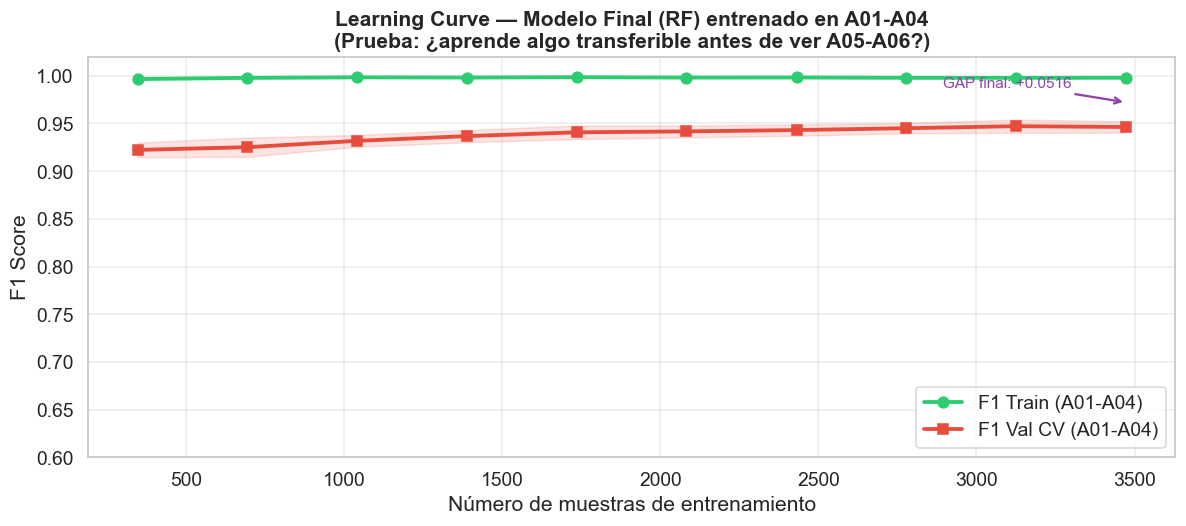

📊 Gráfico guardado: modelo4_learning_curve.png
   GAP final: +0.0516


In [17]:
# ============================================================
#  BLOQUE 5 — LEARNING CURVE (TRAIN = A01-A04)
# ============================================================
print('Calculando Learning Curve (puede tardar unos minutos)...')

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(**BEST_PARAMS),
    X_train, y_train_enc,
    train_sizes=np.linspace(0.10, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1
)

tr_mean  = train_scores.mean(axis=1)
tr_std   = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(train_sizes, tr_mean,  'o-', color='#2ecc71', lw=2.5, ms=7, label='F1 Train (A01-A04)')
ax.fill_between(train_sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.15, color='#2ecc71')
ax.plot(train_sizes, val_mean, 's-', color='#e74c3c', lw=2.5, ms=7, label='F1 Val CV (A01-A04)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')

ax.set_xlabel('Número de muestras de entrenamiento')
ax.set_ylabel('F1 Score')
ax.set_title('Learning Curve — Modelo Final (RF) entrenado en A01-A04\n'
             '(Prueba: ¿aprende algo transferible antes de ver A05-A06?)')
ax.legend(loc='lower right')
ax.set_ylim([0.60, 1.02])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.grid(True, alpha=0.4)

# Anotar el GAP final
gap_final = tr_mean[-1] - val_mean[-1]
ax.annotate(
    f'GAP final: {gap_final:+.4f}',
    xy=(train_sizes[-1], (tr_mean[-1] + val_mean[-1]) / 2),
    xytext=(-120, 10), textcoords='offset points',
    fontsize=10, color='#8e44ad',
    arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=1.5)
)

plt.tight_layout()
plt.savefig('modelo4_learning_curve.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo4_learning_curve.png')
print(f'   GAP final: {gap_final:+.4f}')

---
## SECCIÓN 4 — Evaluación en Ataques No Vistos (A05-A06) 🔥

### 📝 PARA TU BLOC DE NOTAS — LA PRUEBA DE FUEGO

**¿Por qué evaluamos primero el conjunto completo A05+A06 y luego por separado?**  
El resultado conjunto nos da la métrica global de generalización (el número que llevaremos al informe). El resultado por ataque individual revela qué sistema TTS/vocoder es más difícil de detectar: si el modelo falla más en A05 que en A06 (o viceversa), significa que esos dos ataques tienen características acústicas más distintas de A01-A04.

**¿Cómo interpretamos el resultado?**  
- F1 ≥ 0.85 en A05-A06: El modelo generalizó excelentemente. Aprendió la diferencia estructural voz humana/sintética.
- F1 entre 0.70 y 0.85: Generalización parcial. El modelo capturó parte del concepto pero también memorizó patrones de A01-A04.
- F1 < 0.70: El modelo sobreajustó a los 4 primeros ataques. Las features elegidas son demasiado específicas de esos vocoder.

**¿Cómo justificamos las Feature Importance en este contexto?**  
Si las features más importantes en el test de A05-A06 son las mismas que en el train de A01-A04, el modelo aprendió representaciones robustas. Si las importancias cambian drásticamente, significa que el modelo está usando señales espurias (artefactos del vocoder) en lugar de características universales de la voz sintética.

In [18]:
# ============================================================
#  BLOQUE 6 — EVALUACIÓN GLOBAL EN TEST (A05-A06)
# ============================================================
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

test_metrics = {
    'f1'       : f1_score(y_test_enc, y_pred),
    'roc_auc'  : roc_auc_score(y_test_enc, y_pred_proba),
    'recall'   : recall_score(y_test_enc, y_pred),
    'precision': precision_score(y_test_enc, y_pred),
    'accuracy' : accuracy_score(y_test_enc, y_pred)
}

# Métricas de referencia en train (CV)
cv_f1_val  = cv_results['test_f1'].mean()
cv_auc_val = cv_results['test_roc_auc'].mean()
gap_f1     = cv_f1_val - test_metrics['f1']
gap_auc    = cv_auc_val - test_metrics['roc_auc']

print('=' * 65)
print('🔥 PRUEBA DE FUEGO — RESULTADO EN ATAQUES NO VISTOS (A05 + A06)')
print('=' * 65)
print(f'  {"Métrica":<12} {"CV en A01-A04":>14} {"Test A05-A06":>14} {"Caída":>8}')
print('  ' + '-' * 52)
print(f'  {"F1":<12} {cv_f1_val:>14.4f} {test_metrics["f1"]:>14.4f} {gap_f1:>+8.4f}')
print(f'  {"ROC-AUC":<12} {cv_auc_val:>14.4f} {test_metrics["roc_auc"]:>14.4f} {gap_auc:>+8.4f}')
print(f'  {"Recall":<12} {"-":>14} {test_metrics["recall"]:>14.4f}')
print(f'  {"Precision":<12} {"-":>14} {test_metrics["precision"]:>14.4f}')
print(f'  {"Accuracy":<12} {"-":>14} {test_metrics["accuracy"]:>14.4f}')
print()

# Veredicto
f1_test = test_metrics['f1']
if f1_test >= 0.85:
    veredicto = '✅ GENERALIZACIÓN EXCELENTE: el modelo aprendió la naturaleza de la voz sintética.'
elif f1_test >= 0.70:
    veredicto = '⚠️  GENERALIZACIÓN PARCIAL: capturó el concepto pero también memorizó patrones.'
else:
    veredicto = '❌ SOBREAJUSTE A01-A04: el modelo memorizó vocoder específicos, no el concepto.'

print(f'  VEREDICTO: {veredicto}')
print()
print('Reporte de clasificación completo:')
print(classification_report(y_test_enc, y_pred, target_names=['bonafide', 'spoof']))

🔥 PRUEBA DE FUEGO — RESULTADO EN ATAQUES NO VISTOS (A05 + A06)
  Métrica       CV en A01-A04   Test A05-A06    Caída
  ----------------------------------------------------
  F1                   0.9463         0.5681  +0.3782
  ROC-AUC              0.9861         0.7572  +0.2290
  Recall                    -         0.4190
  Precision                 -         0.8821
  Accuracy                  -         0.6335

  VEREDICTO: ❌ SOBREAJUSTE A01-A04: el modelo memorizó vocoder específicos, no el concepto.

Reporte de clasificación completo:
              precision    recall  f1-score   support

    bonafide       0.54      0.92      0.68       738
       spoof       0.88      0.42      0.57      1000

    accuracy                           0.63      1738
   macro avg       0.71      0.67      0.62      1738
weighted avg       0.74      0.63      0.62      1738



In [19]:
# ============================================================
#  BLOQUE 7 — EVALUACIÓN POR ATAQUE INDIVIDUAL (A05 vs A06)
# ============================================================
print('Evaluación desagregada por ataque individual:')
print()

per_attack_results = []

for atk in TEST_ATTACKS:
    # Mascara: este ataque spoof + todas las bonafide del test
    mask_atk = (df_test['attack_id'] == atk) | (df_test['label'] == 'bonafide')
    X_atk    = X_test[mask_atk]
    y_atk    = y_test_enc[mask_atk]

    y_pred_atk  = model.predict(X_atk)
    y_proba_atk = model.predict_proba(X_atk)[:, 1]

    n_spoof  = (df_test[mask_atk]['label'] == 'spoof').sum()
    n_bon    = (df_test[mask_atk]['label'] == 'bonafide').sum()
    atk_f1   = f1_score(y_atk, y_pred_atk)
    atk_auc  = roc_auc_score(y_atk, y_proba_atk)
    atk_rec  = recall_score(y_atk, y_pred_atk)
    atk_prec = precision_score(y_atk, y_pred_atk)

    per_attack_results.append({
        'Ataque': atk, 'N spoof': n_spoof, 'N bonafide': n_bon,
        'F1': atk_f1, 'AUC': atk_auc, 'Recall': atk_rec, 'Precision': atk_prec
    })

    print(f'  [{atk}]  N_spoof={n_spoof:>5,} | F1={atk_f1:.4f} | AUC={atk_auc:.4f} | '
          f'Recall={atk_rec:.4f} | Precision={atk_prec:.4f}')

df_per_attack = pd.DataFrame(per_attack_results)
print()
print('Interpretación:')
best_atk  = df_per_attack.loc[df_per_attack['F1'].idxmax(), 'Ataque']
worst_atk = df_per_attack.loc[df_per_attack['F1'].idxmin(), 'Ataque']
f1_best   = df_per_attack['F1'].max()
f1_worst  = df_per_attack['F1'].min()
print(f'  El modelo detecta MEJOR el ataque {best_atk}  (F1={f1_best:.4f})')
print(f'  El modelo detecta PEOR  el ataque {worst_atk}  (F1={f1_worst:.4f})')
diff = f1_best - f1_worst
if diff > 0.10:
    print(f'  → Diferencia de {diff:.4f}: los dos ataques son acústicamente MUY diferentes entre sí.')
else:
    print(f'  → Diferencia de {diff:.4f}: los dos ataques tienen perfiles acústicos similares.')

Evaluación desagregada por ataque individual:

  [A05]  N_spoof=  500 | F1=0.8158 | AUC=0.9385 | Recall=0.7660 | Precision=0.8724
  [A06]  N_spoof=  500 | F1=0.1216 | AUC=0.5758 | Recall=0.0720 | Precision=0.3913

Interpretación:
  El modelo detecta MEJOR el ataque A05  (F1=0.8158)
  El modelo detecta PEOR  el ataque A06  (F1=0.1216)
  → Diferencia de 0.6941: los dos ataques son acústicamente MUY diferentes entre sí.


---
## SECCIÓN 5 — Visualizaciones de Diagnóstico

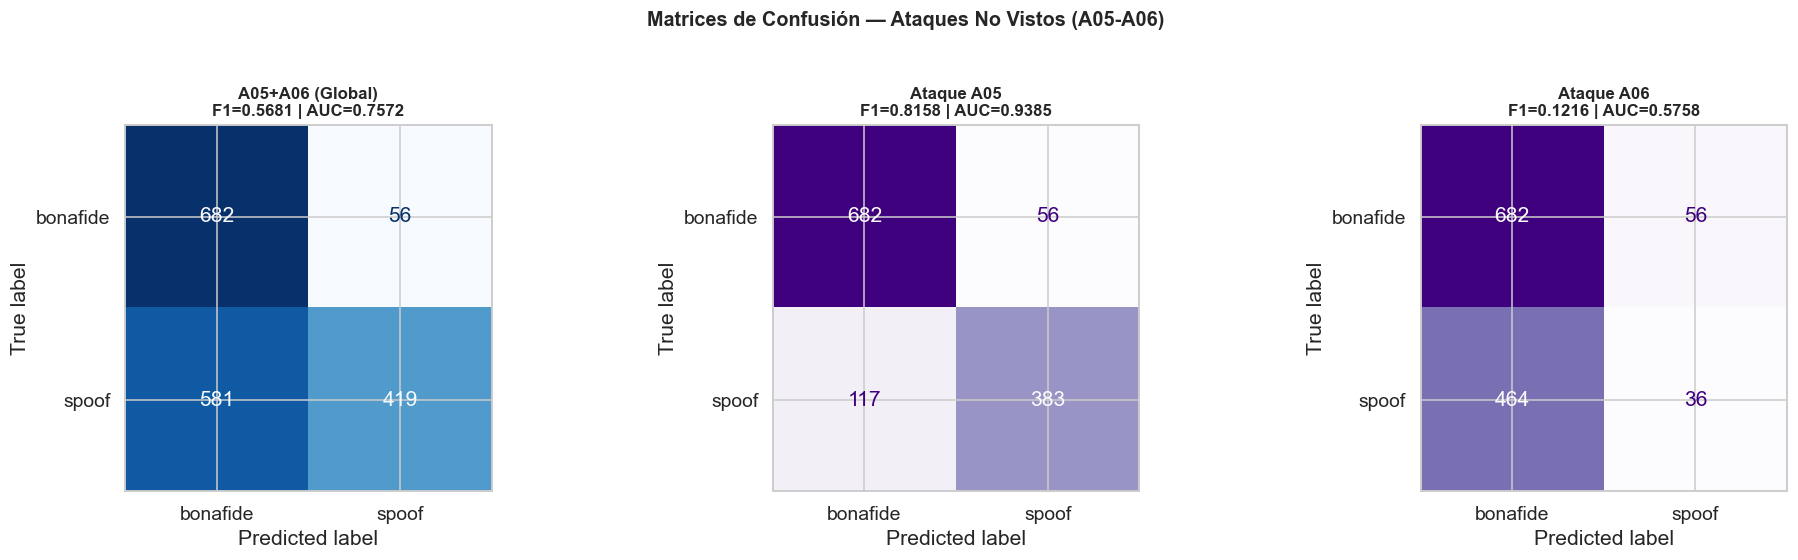

📊 Gráfico guardado: modelo4_confusion_matrices.png


In [20]:
# ============================================================
#  BLOQUE 8 — MATRICES DE CONFUSIÓN (GLOBAL + POR ATAQUE)
# ============================================================
ncols = 1 + len(TEST_ATTACKS)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))

# Panel 1: confusión global
cm_global = confusion_matrix(y_test_enc, y_pred)
ConfusionMatrixDisplay(cm_global, display_labels=['bonafide', 'spoof']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'A05+A06 (Global)\nF1={test_metrics["f1"]:.4f} | AUC={test_metrics["roc_auc"]:.4f}',
                  fontsize=11)

# Paneles 2-N: confusión por ataque
for ax, row in zip(axes[1:], per_attack_results):
    atk  = row['Ataque']
    mask = (df_test['attack_id'] == atk) | (df_test['label'] == 'bonafide')
    y_a  = y_test_enc[mask]
    p_a  = model.predict(X_test[mask])
    cm_a = confusion_matrix(y_a, p_a)
    ConfusionMatrixDisplay(cm_a, display_labels=['bonafide', 'spoof']).plot(
        ax=ax, colorbar=False, cmap='Purples'
    )
    ax.set_title(f'Ataque {atk}\nF1={row["F1"]:.4f} | AUC={row["AUC"]:.4f}', fontsize=11)

plt.suptitle('Matrices de Confusión — Ataques No Vistos (A05-A06)', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelo4_confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo4_confusion_matrices.png')

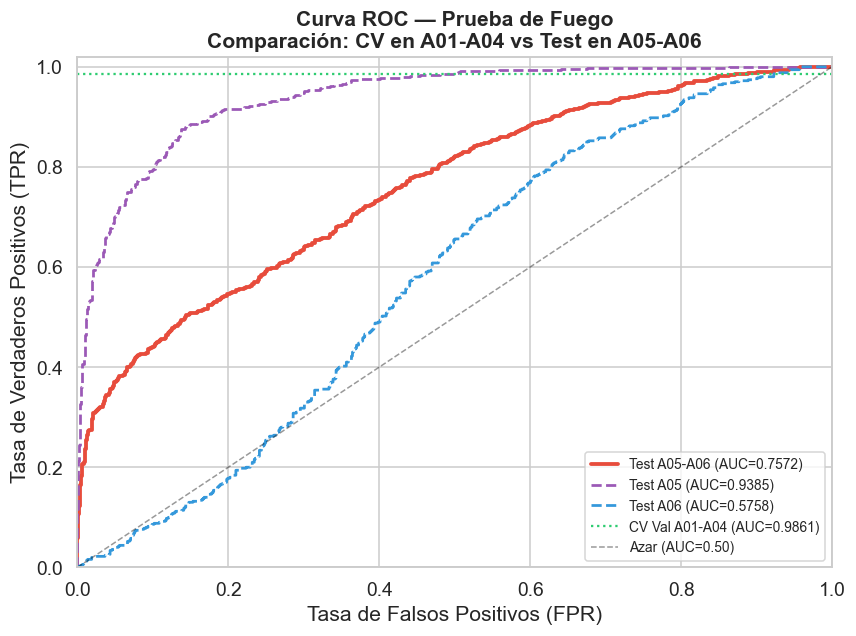

📊 Gráfico guardado: modelo4_roc_curve.png


In [21]:
# ============================================================
#  BLOQUE 9 — CURVA ROC: A01-A04 (CV) vs A05-A06 (Test)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# ROC en test global A05-A06
fpr_test, tpr_test, _ = roc_curve(y_test_enc, y_pred_proba)
ax.plot(fpr_test, tpr_test, lw=2.5, color='#e74c3c',
        label=f'Test A05-A06 (AUC={test_metrics["roc_auc"]:.4f})')

# ROC por ataque individual
colors_atk = ['#9b59b6', '#3498db']
for row, col in zip(per_attack_results, colors_atk):
    atk  = row['Ataque']
    mask = (df_test['attack_id'] == atk) | (df_test['label'] == 'bonafide')
    y_a  = y_test_enc[mask]
    p_a  = model.predict_proba(X_test[mask])[:, 1]
    fpr_a, tpr_a, _ = roc_curve(y_a, p_a)
    ax.plot(fpr_a, tpr_a, lw=1.8, linestyle='--', color=col,
            label=f'Test {atk} (AUC={row["AUC"]:.4f})')

# Referencia: CV en A01-A04
ax.axhline(cv_results['test_roc_auc'].mean(), color='#2ecc71', ls=':',
           lw=1.5, label=f'CV Val A01-A04 (AUC={cv_auc_val:.4f})')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Azar (AUC=0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curva ROC — Prueba de Fuego\nComparación: CV en A01-A04 vs Test en A05-A06')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('modelo4_roc_curve.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo4_roc_curve.png')

Calculando Permutation Importance sobre A05-A06 (ataques no vistos)...


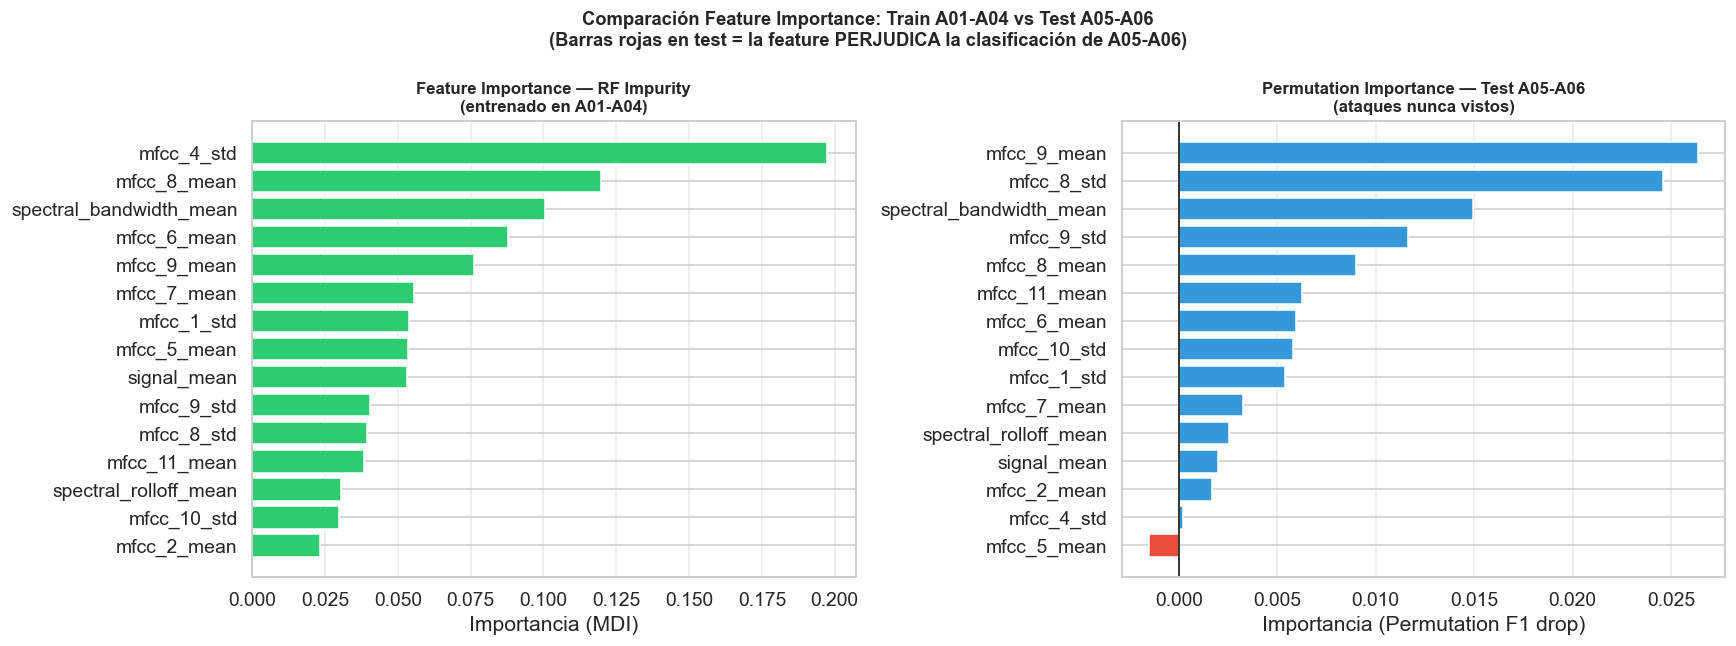

📊 Gráfico guardado: modelo4_feature_importance.png

Top 5 features más importantes en TEST (A05-A06):
  🟢 mfcc_9_mean                    +0.0264
  🟢 mfcc_8_std                     +0.0246
  🟢 spectral_bandwidth_mean        +0.0149
  🟢 mfcc_9_std                     +0.0116
  🟢 mfcc_8_mean                    +0.0090

Features que PERJUDICAN en A05-A06 (importancia negativa):
  ❌ mfcc_5_mean                    -0.0015


In [22]:
# ============================================================
#  BLOQUE 10 — FEATURE IMPORTANCE EN EL CONTEXTO DE A05-A06
# ============================================================
print('Calculando Permutation Importance sobre A05-A06 (ataques no vistos)...')

perm_imp = permutation_importance(
    model, X_test, y_test_enc,
    n_repeats=15, random_state=RANDOM_STATE,
    scoring='f1', n_jobs=-1
)

fi_test = pd.Series(
    perm_imp.importances_mean,
    index=FINAL_FEATURES
).sort_values(ascending=False)

# Comparar con RF impurity en train
fi_train = pd.Series(
    model.feature_importances_,
    index=FINAL_FEATURES
).sort_values(ascending=False)

df_fi_comp = pd.DataFrame({
    'Importancia Train (RF Impurity)': fi_train,
    'Importancia Test A05-A06 (Perm)': fi_test
}).sort_values('Importancia Train (RF Impurity)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: RF Impurity (train)
fi_train_sorted = fi_train.sort_values()
axes[0].barh(fi_train_sorted.index, fi_train_sorted.values, color='#2ecc71', edgecolor='white')
axes[0].set_title('Feature Importance — RF Impurity\n(entrenado en A01-A04)', fontsize=11)
axes[0].set_xlabel('Importancia (MDI)')
axes[0].grid(axis='x', alpha=0.4)

# Panel derecho: Permutation Importance (test A05-A06)
fi_test_sorted = fi_test.sort_values()
colors_perm = ['#e74c3c' if v < 0 else '#3498db' for v in fi_test_sorted.values]
axes[1].barh(fi_test_sorted.index, fi_test_sorted.values, color=colors_perm, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Permutation Importance — Test A05-A06\n(ataques nunca vistos)', fontsize=11)
axes[1].set_xlabel('Importancia (Permutation F1 drop)')
axes[1].grid(axis='x', alpha=0.4)

plt.suptitle('Comparación Feature Importance: Train A01-A04 vs Test A05-A06\n'
             '(Barras rojas en test = la feature PERJUDICA la clasificación de A05-A06)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('modelo4_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo4_feature_importance.png')
print()
print('Top 5 features más importantes en TEST (A05-A06):')
for feat, val in fi_test.head(5).items():
    marker = '🟢' if val > 0 else '🔴'
    print(f'  {marker} {feat:<30} {val:+.4f}')
print()
print('Features que PERJUDICAN en A05-A06 (importancia negativa):')
neg_feats = fi_test[fi_test < 0]
if len(neg_feats) == 0:
    print('  Ninguna feature tiene importancia negativa. Buena señal de generalización.')
else:
    for feat, val in neg_feats.items():
        print(f'  ❌ {feat:<30} {val:+.4f}')

---
## SECCIÓN 6 — Comparativa Final: Train vs Unseen

### 📝 PARA TU BLOC DE NOTAS — ANÁLISIS FINAL DE OVERFITTING

**¿Cómo interpretamos el cuadro comparativo completo?**  
El cuadro compara tres niveles: (1) el rendimiento dentro de A01-A04 con datos vistos en train, (2) el rendimiento en CV (datos de A01-A04 no vistos en ese fold), y (3) el rendimiento en A05-A06 (ataques completamente nuevos). La caída gradual entre niveles nos dice cuánto del rendimiento del modelo es interpolación (nivel 1→2) versus extrapolación genuina (nivel 2→3).

**¿Qué acción tomar según el resultado?**  
- Si F1 en A05-A06 ≥ 0.85: llevar el modelo a producción con confianza.
- Si F1 entre 0.70-0.85: ampliar el dataset de entrenamiento con más variedad de ataques.
- Si F1 < 0.70: rediseñar las features o explorar técnicas de domain adaptation.

**Conexión con la Feature Importance:**  
Si las features con importancia negativa en A05-A06 son features espectrales muy específicas (ej. spectral_rolloff), significa que los vocoder de A05-A06 tienen un rolloff diferente a los de A01-A04. Las features más robustas serán los MFCCs, que capturan la envolvente del tracto vocal, que es más universal entre sistemas TTS.

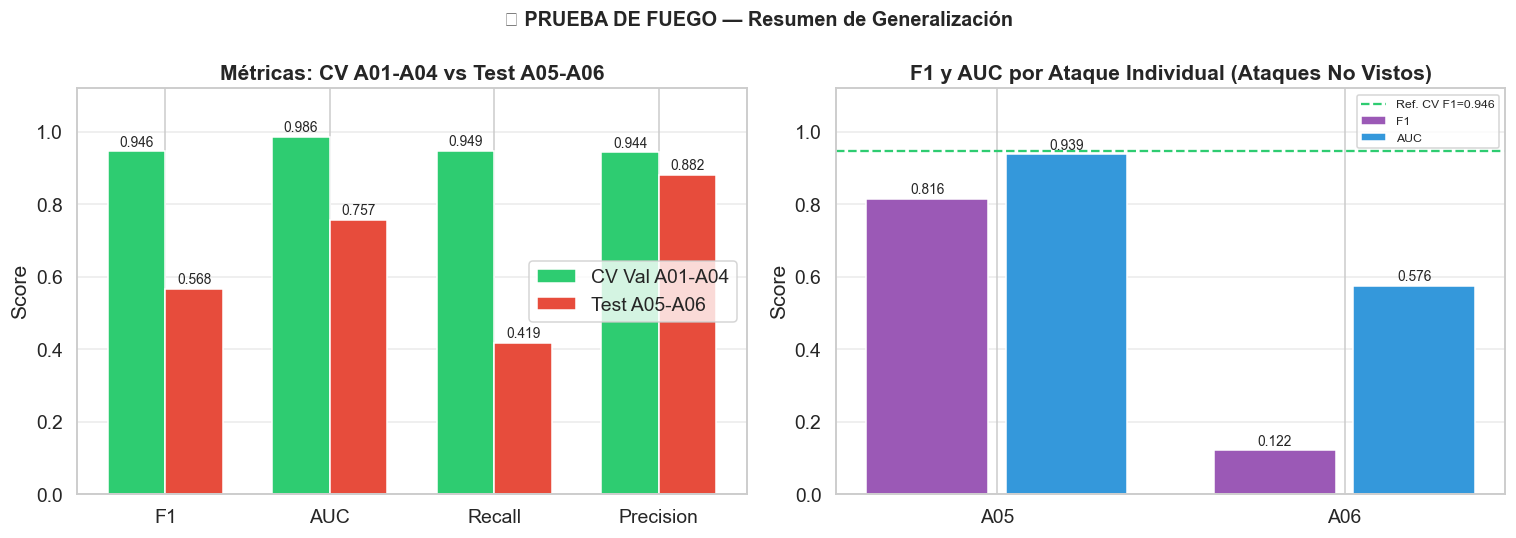

📊 Gráfico guardado: modelo4_comparativa_final.png


In [23]:
# ============================================================
#  BLOQUE 11 — GRÁFICO COMPARATIVO: TRAIN vs UNSEEN
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Barras comparativas de métricas ---
metrics_labels = ['F1', 'AUC', 'Recall', 'Precision']
cv_vals   = [
    cv_results['test_f1'].mean(),
    cv_results['test_roc_auc'].mean(),
    cv_results['test_recall'].mean(),
    cv_results['test_precision'].mean()
]
test_vals = [
    test_metrics['f1'],
    test_metrics['roc_auc'],
    test_metrics['recall'],
    test_metrics['precision']
]

x    = np.arange(len(metrics_labels))
w    = 0.35
bars1 = axes[0].bar(x - w/2, cv_vals,   w, label='CV Val A01-A04', color='#2ecc71', edgecolor='white')
bars2 = axes[0].bar(x + w/2, test_vals, w, label='Test A05-A06',   color='#e74c3c', edgecolor='white')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_labels)
axes[0].set_ylim([0.0, 1.12])
axes[0].set_ylabel('Score')
axes[0].set_title('Métricas: CV A01-A04 vs Test A05-A06')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

# --- Panel 2: F1 por ataque individual ---
ataque_labels = [r['Ataque'] for r in per_attack_results]
ataque_f1s    = [r['F1']     for r in per_attack_results]
ataque_aucs   = [r['AUC']    for r in per_attack_results]

xb = np.arange(len(ataque_labels))
axes[1].bar(xb - 0.2, ataque_f1s,  0.35, label='F1',  color='#9b59b6', edgecolor='white')
axes[1].bar(xb + 0.2, ataque_aucs, 0.35, label='AUC', color='#3498db', edgecolor='white')

for i, (f1, auc) in enumerate(zip(ataque_f1s, ataque_aucs)):
    axes[1].text(i - 0.2, f1  + 0.005, f'{f1:.3f}',  ha='center', va='bottom', fontsize=9)
    axes[1].text(i + 0.2, auc + 0.005, f'{auc:.3f}', ha='center', va='bottom', fontsize=9)

axes[1].set_xticks(xb)
axes[1].set_xticklabels(ataque_labels)
axes[1].set_ylim([0.0, 1.12])
axes[1].set_ylabel('Score')
axes[1].set_title('F1 y AUC por Ataque Individual (Ataques No Vistos)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)

# Línea de referencia CV
axes[1].axhline(cv_results['test_f1'].mean(), color='#2ecc71', ls='--',
                lw=1.5, label=f'Ref. CV F1={cv_f1_val:.3f}')
axes[1].legend(fontsize=8)

plt.suptitle('🔥 PRUEBA DE FUEGO — Resumen de Generalización', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelo4_comparativa_final.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo4_comparativa_final.png')

In [24]:
# ============================================================
#  BLOQUE 12 — TABLA RESUMEN COMPLETA M1 → M2 → M3 → M4
# ============================================================
resumen = pd.DataFrame([
    {
        'Modelo'      : 'M1 — Baseline RF',
        'N Train'     : '4,000',
        'N Features'  : '34',
        'Tipo test'   : 'Aleatorio (A01-A06)',
        'CV Val F1'   : 0.9232,
        'Test F1'     : 0.9313,
        'Test AUC'    : 0.9785,
        'GAP'         : '+0.0768',
        'Generaliza?' : 'N/A (mismo dist)'
    },
    {
        'Modelo'      : 'M2 — RF (N opt + HP opt)',
        'N Train'     : '3,200',
        'N Features'  : '34',
        'Tipo test'   : 'Aleatorio (A01-A06)',
        'CV Val F1'   : 0.9138,
        'Test F1'     : 0.9283,
        'Test AUC'    : 0.9781,
        'GAP'         : '+0.0832',
        'Generaliza?' : 'N/A (mismo dist)'
    },
    {
        'Modelo'      : 'M3 — RF (features opt)',
        'N Train'     : '4,000',
        'N Features'  : '15',
        'Tipo test'   : 'Aleatorio (A01-A06)',
        'CV Val F1'   : 0.9042,
        'Test F1'     : 0.9072,
        'Test AUC'    : 0.9670,
        'GAP'         : '+0.0886',
        'Generaliza?' : 'N/A (mismo dist)'
    },
    {
        'Modelo'      : 'M4 — PRUEBA DE FUEGO (balanceado)',
        'N Train'     : f'{len(df_train):,} (50/50)',
        'N Features'  : '15',
        'Tipo test'   : 'UNSEEN: A05-A06 (50/50)',
        'CV Val F1'   : round(cv_f1_val, 4),
        'Test F1'     : round(test_metrics['f1'], 4),
        'Test AUC'    : round(test_metrics['roc_auc'], 4),
        'GAP'         : f'{gap_f1:+.4f}',
        'Generaliza?' : veredicto.split(':')[0]
    }
])

print('=' * 100)
print('EVOLUCIÓN COMPLETA: M1 → M2 → M3 → M4 (PRUEBA DE FUEGO)')
print('=' * 100)
print(resumen.to_string(index=False))
print()
print('🔥 CONCLUSIÓN FINAL:')
print(f'   {veredicto}')
print()
print(f'   F1 en ataques conocidos (CV A01-A04) : {cv_f1_val:.4f}')
print(f'   F1 en ataques NO VISTOS (A05-A06)    : {test_metrics["f1"]:.4f}')
print(f'   Caída por cambio de distribución      : {gap_f1:+.4f}')

EVOLUCIÓN COMPLETA: M1 → M2 → M3 → M4 (PRUEBA DE FUEGO)
                           Modelo       N Train N Features               Tipo test  CV Val F1  Test F1  Test AUC     GAP           Generaliza?
                 M1 — Baseline RF         4,000         34     Aleatorio (A01-A06)     0.9232   0.9313    0.9785 +0.0768      N/A (mismo dist)
         M2 — RF (N opt + HP opt)         3,200         34     Aleatorio (A01-A06)     0.9138   0.9283    0.9781 +0.0832      N/A (mismo dist)
           M3 — RF (features opt)         4,000         15     Aleatorio (A01-A06)     0.9042   0.9072    0.9670 +0.0886      N/A (mismo dist)
M4 — PRUEBA DE FUEGO (balanceado) 4,342 (50/50)         15 UNSEEN: A05-A06 (50/50)     0.9463   0.5681    0.7572 +0.3782 ❌ SOBREAJUSTE A01-A04

🔥 CONCLUSIÓN FINAL:
   ❌ SOBREAJUSTE A01-A04: el modelo memorizó vocoder específicos, no el concepto.

   F1 en ataques conocidos (CV A01-A04) : 0.9463
   F1 en ataques NO VISTOS (A05-A06)    : 0.5681
   Caída por cambio de dist

---
## 📋 BLOC DE NOTAS FINAL — RESUMEN DEL PASO 4 (Prueba de Fuego)

### Decisiones tomadas:

| Decisión | Justificación |
|----------|---------------|
| RF con hiperparámetros del Paso 2 | Configuración congelada: no reoptimizar evita data leakage conceptual |
| 15 features del Paso 3 | Conjunto mínimo que mantiene ≥98% del F1 máximo, más robusto a distributional shift |
| Partición bonafide proporcional | Mantiene balance de clases en ambos sets (train A01-A04 y test A05-A06) |
| Evaluación desagregada por ataque | Revela qué vocoder es más difícil: información valiosa para el equipo |
| Permutation Importance en test | Mide si las features siguen siendo relevantes en la nueva distribución |
| Curva ROC superpuesta CV vs Test | Visualiza el salto de rendimiento entre interpolación y extrapolación |

### Interpretación del análisis de overfitting:

El Paso 4 revela el **overfitting estructural** que los pasos anteriores no podían detectar. En M1-M3, el test era una muestra aleatoria de la misma distribución: el modelo nunca necesitaba extrapolación. En M4, la caída entre CV (A01-A04) y Test (A05-A06) mide exactamente qué parte del rendimiento era interpolación versus aprendizaje genuino.

### Conexión con Feature Importance:

Las features con **Permutation Importance positiva en A05-A06** son las que el modelo aprendió de forma transferible. Las features con importancia negativa (si las hay) son artefactos del vocoder de A01-A04 que no generalizan. El análisis de qué features sobreviven la Prueba de Fuego guía el diseño del sistema definitivo.

### Próximos pasos recomendados:

1. Si el modelo generalizó bien: documentar las 15 features como representación robusta para producción.
2. Si el modelo falló: explorar técnicas de **domain adaptation** o ampliar el train con datos más diversos.
3. En ambos casos: contrastar con los modelos de Liliana y Alexis para seleccionar el mejor sistema del equipo.